<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 111 · Model Evaluation</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Model Evaluation</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Measuring a model honestly on an imbalanced fraud table: why accuracy lies, the confusion matrix, precision / recall / F1, the threshold trade-off and PR curve, ROC-AUC, and the regression metrics MAE / MSE / RMSE / R-squared, all library-first and visual.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Model Evaluation: measuring a model honestly
A model has learned, but is it any good? **Accuracy alone can be a trap**, especially on imbalanced data. This notebook builds the real toolkit on a fraud-detection table: the **confusion matrix**, **precision / recall / F1**, the **threshold** that trades one for the other, the **ROC curve and AUC**, and the regression metrics **MAE, MSE, RMSE, R-squared**. Library-first with `scikit-learn`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_score, recall_score, f1_score, accuracy_score, precision_recall_curve,
    roc_curve, roc_auc_score, average_precision_score, mean_absolute_error, mean_squared_error, r2_score)
pd.set_option('display.max_columns', 30)

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 1 &#183; WHY ACCURACY LIES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">On imbalanced data, doing nothing looks great</div>
<div style="color:#4a5578;margin-top:6px">A model that flags no fraud can still be 87% accurate.</div>
</div>

In [3]:
try: df = pd.read_excel('../../data/ch111_transactions.xlsx', sheet_name='Data')
except FileNotFoundError: df = pd.read_excel(BASE + 'ch111_transactions.xlsx', sheet_name='Data')
feat = ['amount','hour','account_age_days','txns_last_hour','foreign','high_risk_merchant']
X, y = df[feat], df['is_fraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
print(f'fraud rate = {y.mean():.1%}')
print(f'"flag nothing" accuracy = {accuracy_score(y_test, dummy.predict(X_test)):.3f}  but recall = {recall_score(y_test, dummy.predict(X_test)):.3f}  (catches ZERO fraud)')
clf = GradientBoostingClassifier(random_state=0).fit(X_train, y_train)
print(f'real model accuracy    = {accuracy_score(y_test, clf.predict(X_test)):.3f}  (barely higher, yet it actually catches fraud)')

fraud rate = 12.9%
"flag nothing" accuracy = 0.871  but recall = 0.000  (catches ZERO fraud)
real model accuracy    = 0.873  (barely higher, yet it actually catches fraud)


**The trap.** With only **13% fraud**, a model that predicts *legitimate* for everyone is **87% accurate**, and completely useless: it catches **zero** fraud. Our real model has almost the same accuracy (87%), yet it is genuinely valuable. **Accuracy hides the failure** because the majority class dominates it. On imbalanced problems, and most important problems are imbalanced, we need metrics that look at the minority class directly.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 2 &#183; THE CONFUSION MATRIX &amp; PRECISION / RECALL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Four outcomes, two key ratios</div>
<div style="color:#4a5578;margin-top:6px">Every classification metric is built from these four counts.</div>
</div>

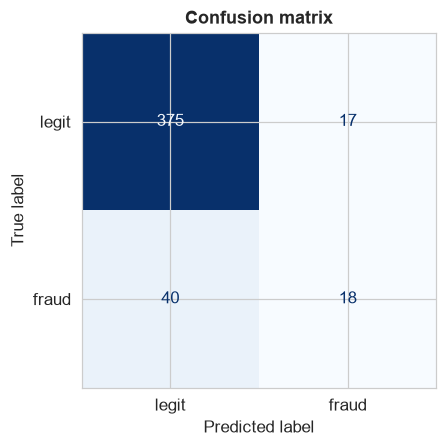

              precision    recall  f1-score   support

       legit       0.90      0.96      0.93       392
       fraud       0.51      0.31      0.39        58

    accuracy                           0.87       450
   macro avg       0.71      0.63      0.66       450
weighted avg       0.85      0.87      0.86       450

precision = 0.514  (of flagged transactions, how many were really fraud)
recall    = 0.310  (of all fraud, how many we caught)
F1        = 0.387  (harmonic mean of precision and recall)


In [4]:
pred = clf.predict(X_test)
fig, ax = plt.subplots(figsize=(4.8,4.2))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=['legit','fraud']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion matrix'); plt.tight_layout(); plt.show()
print(classification_report(y_test, pred, target_names=['legit','fraud']))
print(f'precision = {precision_score(y_test,pred):.3f}  (of flagged transactions, how many were really fraud)')
print(f'recall    = {recall_score(y_test,pred):.3f}  (of all fraud, how many we caught)')
print(f'F1        = {f1_score(y_test,pred):.3f}  (harmonic mean of precision and recall)')

**Reading the matrix.** The four cells are **true positives** (fraud caught), **false positives** (legit flagged by mistake), **false negatives** (fraud missed), and **true negatives**. From them: **precision** = TP / (TP + FP), *of the transactions we flagged, how many were actually fraud* (the cost of false alarms); **recall** = TP / (TP + FN), *of all the fraud, how much we caught* (the cost of misses). **F1** balances the two. Which matters more is a business decision: a fraud team fears missed fraud (recall), a spam filter fears blocking real mail (precision).

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 3 &#183; THE THRESHOLD TRADE-OFF</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Precision and recall move in opposite directions</div>
<div style="color:#4a5578;margin-top:6px">Slide the decision threshold to pick your operating point.</div>
</div>

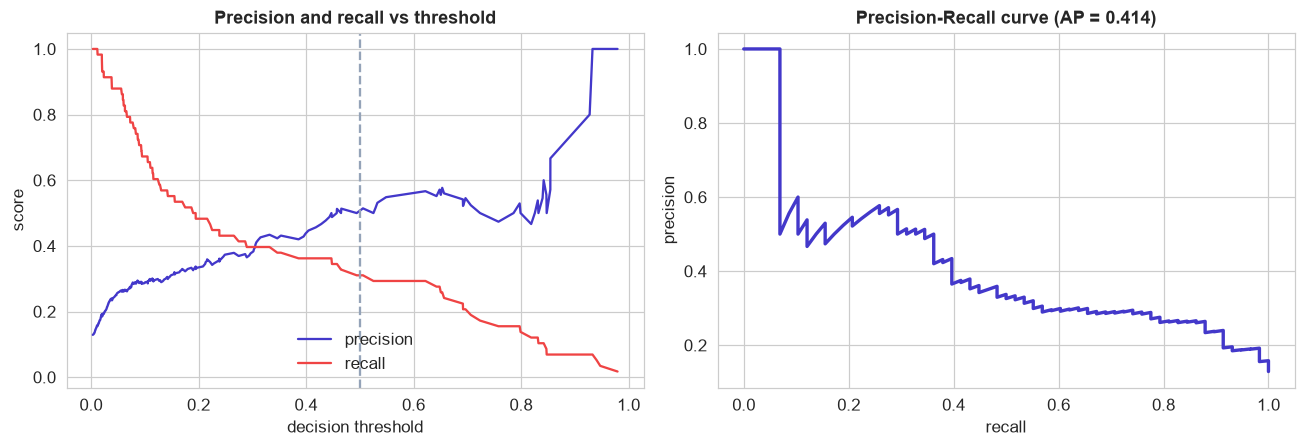

threshold 0.5: precision 0.51, recall 0.31
threshold 0.25: precision 0.38, recall 0.43


In [5]:
proba = clf.predict_proba(X_test)[:,1]
prec, rec, thr = precision_recall_curve(y_test, proba)
fig, ax = plt.subplots(1, 2, figsize=(12,4.2))
ax[0].plot(thr, prec[:-1], color=EM, label='precision'); ax[0].plot(thr, rec[:-1], color=RED, label='recall')
ax[0].axvline(0.5, color=GREY, ls='--'); ax[0].set(title='Precision and recall vs threshold', xlabel='decision threshold', ylabel='score'); ax[0].legend()
ax[1].plot(rec, prec, color=EM, lw=2.2); ax[1].set(title=f'Precision-Recall curve (AP = {average_precision_score(y_test, proba):.3f})', xlabel='recall', ylabel='precision')
plt.tight_layout(); plt.show()
for t in [0.5, 0.25]:
    pp=(proba>=t).astype(int); print(f'threshold {t}: precision {precision_score(y_test,pp):.2f}, recall {recall_score(y_test,pp):.2f}')

**The dial.** A classifier outputs a **probability**; turning it into a yes/no needs a **threshold** (0.5 by default). Lowering the threshold flags more transactions, so **recall rises but precision falls**; raising it does the reverse. The left plot shows the two curves crossing; the **precision-recall curve** (right) summarizes every operating point, and **average precision (AP)** is the area under it, the right summary metric for imbalanced data. You choose the threshold from the **relative cost** of a miss versus a false alarm, not by leaving it at 0.5.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 4 &#183; ROC CURVE &amp; AUC</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A threshold-free score of ranking quality</div>
<div style="color:#4a5578;margin-top:6px">How well does the model rank fraud above legit?</div>
</div>

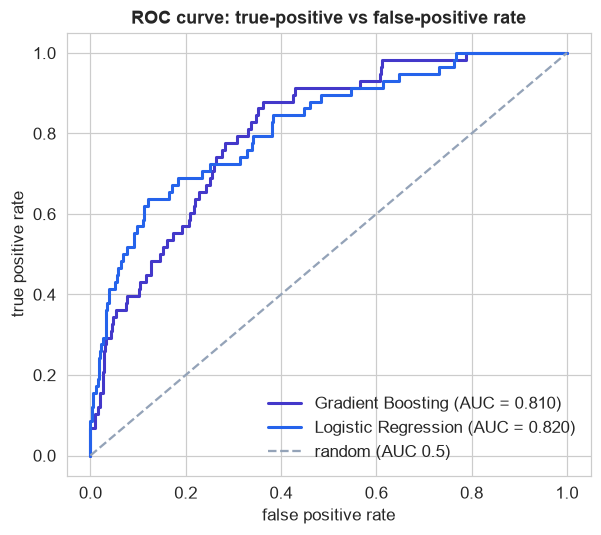

In [6]:
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(5.6,5))
for name, m, c in [('Gradient Boosting', clf, EM), ('Logistic Regression', logit, BLUE)]:
    pr = m.predict_proba(X_test)[:,1]; fpr, tpr, _ = roc_curve(y_test, pr)
    ax.plot(fpr, tpr, color=c, lw=2, label=f'{name} (AUC = {roc_auc_score(y_test, pr):.3f})')
ax.plot([0,1],[0,1], ls='--', color=GREY, label='random (AUC 0.5)')
ax.set(title='ROC curve: true-positive vs false-positive rate', xlabel='false positive rate', ylabel='true positive rate'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

**What AUC measures.** The **ROC curve** plots the true-positive rate (recall) against the false-positive rate as the threshold sweeps from 1 to 0. The **area under it (AUC)** is a single, **threshold-independent** number: the probability that the model ranks a random fraud higher than a random legit transaction. 0.5 is random, 1.0 is perfect; our model scores about **0.81**. AUC is great for **comparing models** and for ranking quality, but on very imbalanced data the **precision-recall / average-precision** view (Demo 3) is often more informative about real-world usefulness.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 5 &#183; REGRESSION METRICS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">When the target is a number</div>
<div style="color:#4a5578;margin-top:6px">MAE, MSE, RMSE, and R-squared each say something different.</div>
</div>

MAE  = 2.29   (average absolute error, in the target's units)
MSE  = 8.39   (squares errors, so big misses are punished hard)
RMSE = 2.90   (square root of MSE, back in the target's units)
R2   = 0.852  (share of variance explained; 1 is perfect, 0 is a flat mean)


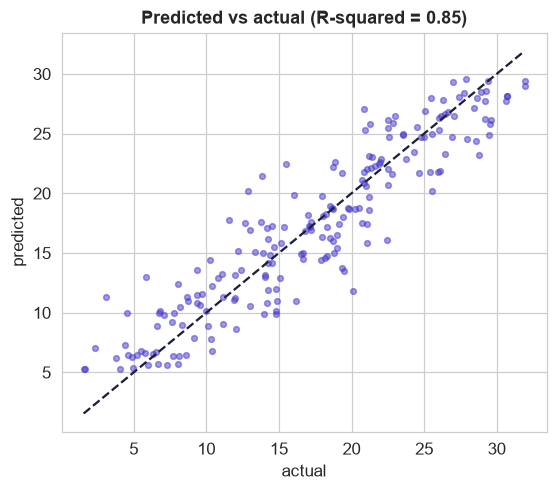

In [7]:
rng = np.random.default_rng(5)
xx = rng.uniform(0, 10, 200); yy = 2.5*xx + 5 + rng.normal(0, 3, 200)     # a simple regression to score
reg = LinearRegression().fit(xx.reshape(-1,1), yy); yhat = reg.predict(xx.reshape(-1,1))
mae = mean_absolute_error(yy, yhat); mse = mean_squared_error(yy, yhat); rmse = mse**0.5; r2 = r2_score(yy, yhat)
print(f'MAE  = {mae:.2f}   (average absolute error, in the target\'s units)')
print(f'MSE  = {mse:.2f}   (squares errors, so big misses are punished hard)')
print(f'RMSE = {rmse:.2f}   (square root of MSE, back in the target\'s units)')
print(f'R2   = {r2:.3f}  (share of variance explained; 1 is perfect, 0 is a flat mean)')
fig, ax = plt.subplots(figsize=(5.2,4.6))
ax.scatter(yy, yhat, s=14, color=EM, alpha=0.5); lims=[yy.min(), yy.max()]; ax.plot(lims, lims, ls='--', color=INK)
ax.set(title=f'Predicted vs actual (R-squared = {r2:.2f})', xlabel='actual', ylabel='predicted'); plt.tight_layout(); plt.show()

**Four numbers for regression.** **MAE** is the average absolute error, easy to read (in the target's units) and robust to outliers. **MSE** squares each error, so a few large misses dominate it; **RMSE** takes the square root to return to the original units, and is the most common single score. **R-squared** reports the fraction of the target's variance the model explains, from the regression chapters, where 1.0 is perfect and 0 means no better than predicting the mean. Report an error metric (RMSE or MAE) *and* R-squared: one gives the size of the typical miss, the other the proportion explained.

## Choosing the right metric

- **Never trust accuracy alone on imbalanced data**, a do-nothing model can score high while catching nothing.
- **Precision** (avoid false alarms) vs **recall** (avoid misses): pick by the cost of each error; **F1** balances them.
- The **threshold** is a knob you tune from business cost, not a fixed 0.5; the **PR curve / average precision** summarizes it.
- **ROC-AUC** is a threshold-free ranking score, great for comparing models; prefer **average precision** when positives are rare.
- For regression: **RMSE or MAE** for the typical error size, plus **R-squared** for the share of variance explained.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>